# Научно-исследовательская работа
## Прогнозирование отклика клиента на банковскую маркетинговую кампанию на основе датасета Bank Marketing (UCI)

**Дисциплина:** Технологии машинного обучения

**Тема:** прогнозирование вероятности того, что клиент банка откроет срочный вклад после телефонной маркетинговой кампании.

**Цель работы:** построить и сравнить несколько моделей классификации (включая ансамблевые) для задачи прогнозирования отклика клиента; обосновать выбор метрик с учётом дисбаланса классов; провести подбор гиперпараметров; сформировать выводы о применимости моделей.

**Структура работы соответствует методическим указаниям к НИРС:**
1. Поиск и описание набора данных.
2. Разведочный анализ данных.
3. Предобработка: обработка пропусков, кодирование категорий, масштабирование, генерация вспомогательных признаков.
4. Корреляционный анализ и промежуточные выводы.
5. Выбор метрик качества (не менее 3) с обоснованием.
6. Выбор моделей (не менее 5, минимум 2 ансамблевых).
7. Разделение на обучающую и тестовую выборки.
8. Baseline без подбора гиперпараметров.
9. Подбор гиперпараметров через кросс-валидацию.
10. Сравнение baseline vs оптимизированные модели.
11. Формирование выводов с графиками.
12. Веб-приложение Streamlit для демонстрации модели (вынесено в отдельный файл `web/app.py`).

## 1. Описание набора данных

Используется датасет **Bank Marketing** из репозитория UCI Machine Learning ([ссылка](https://archive.ics.uci.edu/dataset/222/bank+marketing)). Данные собраны в ходе телефонных маркетинговых кампаний португальского банка по продвижению срочных вкладов в период с мая 2008 по ноябрь 2010 года. Используется расширенная версия `bank-additional-full.csv` (41 188 наблюдений, 20 признаков + целевая переменная).

**Целевая переменная** `y` — открыл ли клиент срочный вклад после контакта (`yes`/`no`). Классы сильно несбалансированы: примерно 11.3 % положительных.

**Группы признаков:**

* *Демография клиента:* `age`, `job`, `marital`, `education`.
* *Кредитная история:* `default`, `housing`, `loan`.
* *Контакт текущей кампании:* `contact`, `month`, `day_of_week`, `duration`, `campaign`.
* *История прошлых кампаний:* `pdays`, `previous`, `poutcome`.
* *Макроэкономические индикаторы:* `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`.

**Важное методологическое замечание.** Признак `duration` (длительность звонка в секундах) **сильно** коррелирует с целевой переменной по построению — если клиент быстро повесил трубку, отклика не будет. Сами авторы датасета указывают: этот признак не известен до начала звонка, поэтому в реалистичной прогнозной модели его использовать нельзя. **В дальнейшем `duration` исключается из признакового пространства** — это сознательное методологическое решение, делающее задачу заметно сложнее, но честнее. Без `duration` качество моделей будет ниже, но результат будет применим в практике.

Признак `pdays = 999` означает «контакта в прошлой кампании не было» — это специальное значение, его нужно обработать отдельно (превратить в бинарный флаг + сами числа использовать только для тех, у кого предыдущий контакт был).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, precision_score, accuracy_score,
    average_precision_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('data.csv', sep=';')
print(f'Размер датасета: {df.shape[0]} наблюдений, {df.shape[1]} столбцов')
df.head()

Размер датасета: 41188 наблюдений, 21 столбцов


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Разведочный анализ данных

### 2.1. Типы данных и базовые характеристики

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,41188.0,NaN,NaN,NaN,40.02406,10.42125,17.0,32.0,38.0,47.0,98.0
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.2. Целевая переменная и дисбаланс классов

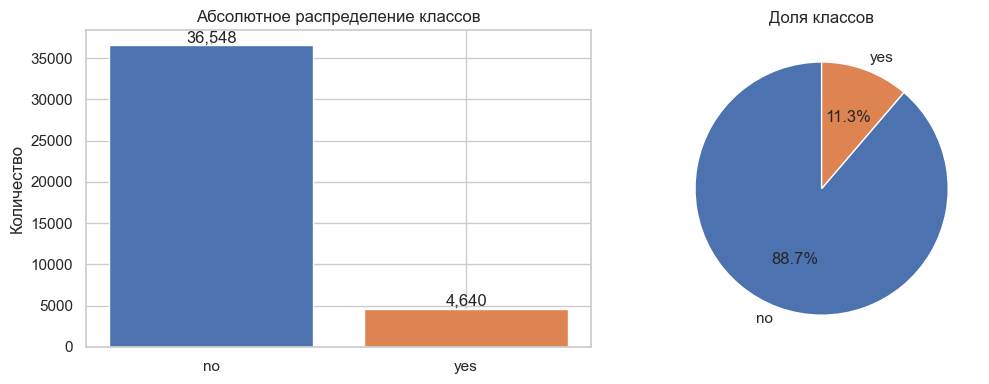

Дисбаланс: позитивный класс составляет 11.27%.
Это значит, что accuracy будет вводить в заблуждение — модель, всегда говорящая «no», даст ≈ 88.7%.


In [5]:
target_counts = df['y'].value_counts()
target_share = df['y'].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(target_counts.index, target_counts.values, color=['#4c72b0', '#dd8452'])
axes[0].set_title('Абсолютное распределение классов')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')
axes[0].set_ylabel('Количество')

axes[1].pie(target_share.values, labels=target_share.index, autopct='%1.1f%%',
            colors=['#4c72b0', '#dd8452'], startangle=90)
axes[1].set_title('Доля классов')
plt.tight_layout()
plt.show()

print(f'Дисбаланс: позитивный класс составляет {target_share["yes"]*100:.2f}%.')
print('Это значит, что accuracy будет вводить в заблуждение — модель, всегда говорящая «no», даст ≈ 88.7%.')

### 2.3. Распределения числовых признаков

Числовые признаки: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


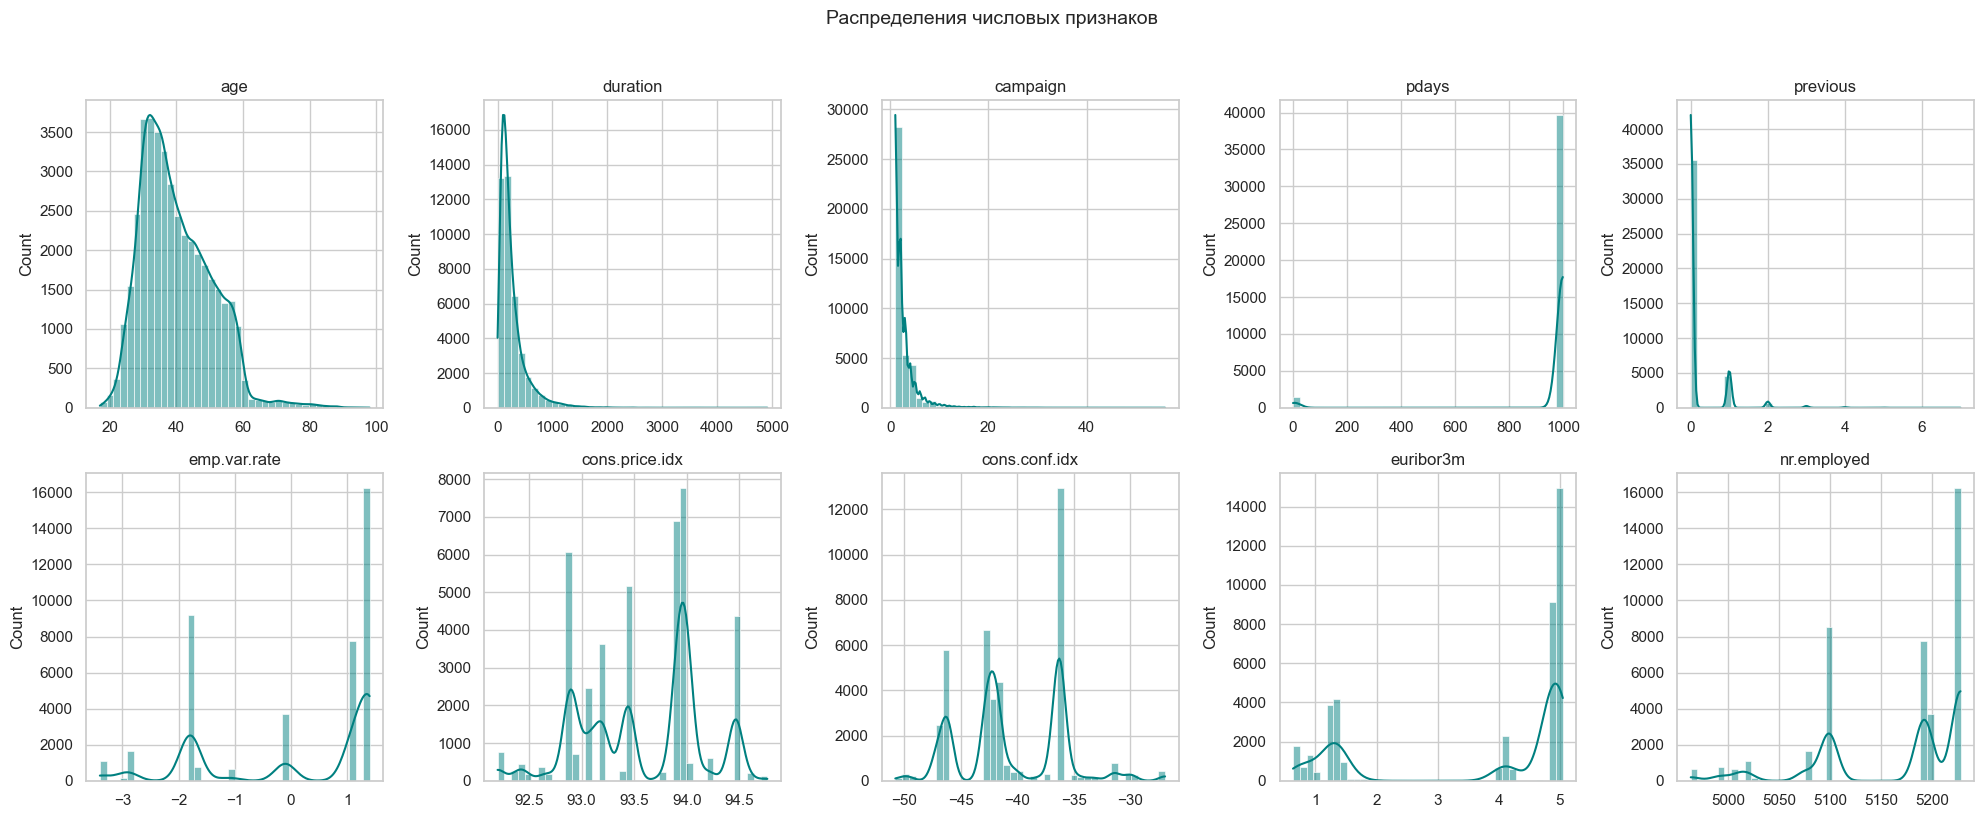

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Числовые признаки:', num_cols)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], bins=40, kde=True, color='teal', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
fig.suptitle('Распределения числовых признаков', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

**Наблюдения:**
* `age` имеет правый хвост — клиенты старше 60 встречаются реже.
* `duration` распределение сильно скошено (большинство звонков короткие) — но этот признак будет удалён по соображениям утечки целевого значения.
* `campaign` (число контактов в текущей кампании) и `previous` — счётчики с длинным правым хвостом.
* `pdays = 999` (нет предыдущего контакта) занимает подавляющую долю — рассмотрим этот признак отдельно.
* Макроэкономические индикаторы (`euribor3m`, `emp.var.rate`, `nr.employed`) имеют несколько чётких уровней — отражает разные периоды кампании.

### 2.4. Распределения категориальных признаков

Категориальные признаки: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


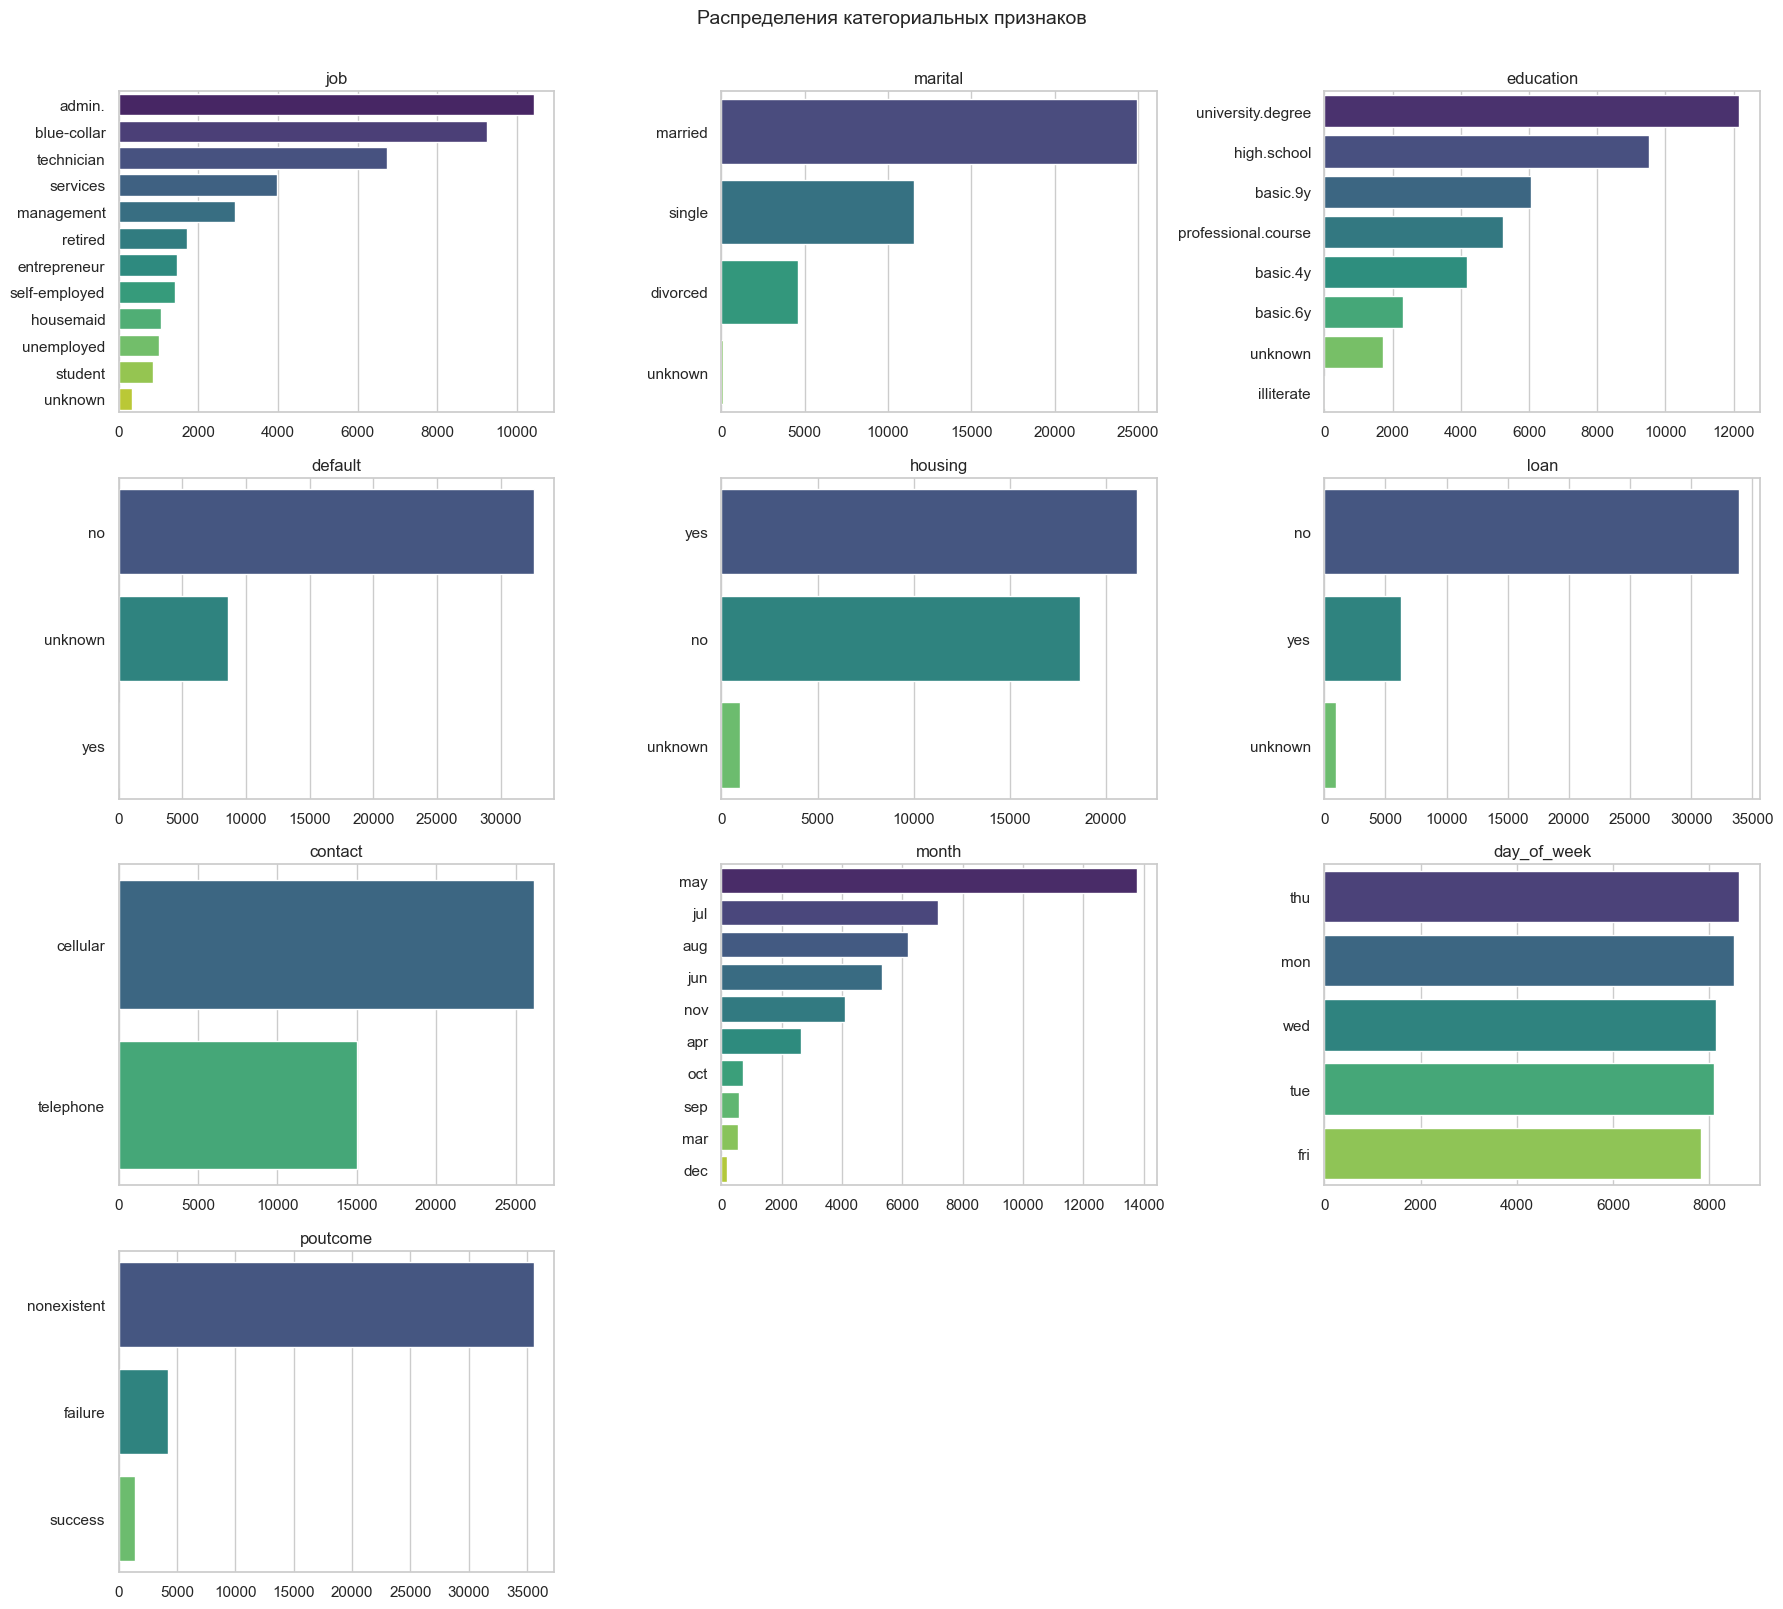

In [7]:
cat_cols = df.select_dtypes(include='object').columns.drop('y').tolist()
print('Категориальные признаки:', cat_cols)

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
for ax, col in zip(axes.flat, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, palette='viridis', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('')
for ax in axes.flat[len(cat_cols):]:
    ax.set_visible(False)
fig.suptitle('Распределения категориальных признаков', y=1.005, fontsize=14)
fig.tight_layout()
plt.show()

### 2.5. Анализ пропусков и значений 'unknown'

В датасете нет `NaN`, но в категориальных признаках есть отдельная категория `'unknown'`, которая фактически отражает пропуск ответа клиента.

In [8]:
print('Явные NaN:', df.isna().sum().sum())
print()
print('Значения "unknown" по категориальным признакам:')
unk = {}
for c in cat_cols:
    n = (df[c] == 'unknown').sum()
    if n > 0:
        unk[c] = n
unk_df = pd.DataFrame.from_dict(unk, orient='index', columns=['count'])
unk_df['percent'] = (unk_df['count'] / len(df) * 100).round(2)
unk_df.sort_values('count', ascending=False)

Явные NaN: 0

Значения "unknown" по категориальным признакам:


,count,percent
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


**Стратегия обработки `unknown`:** оставляем как отдельную категорию. Это даёт OHE дополнительный столбец, и алгоритм сам учится, насколько отсутствие ответа информативно. Удалять строки нецелесообразно — потеряли бы ~21 % данных (по столбцу `default`).

### 2.6. Связь признаков с целевой переменной

Сравним отклик `yes` по категориям ключевых категориальных признаков и распределения числовых признаков по классам.

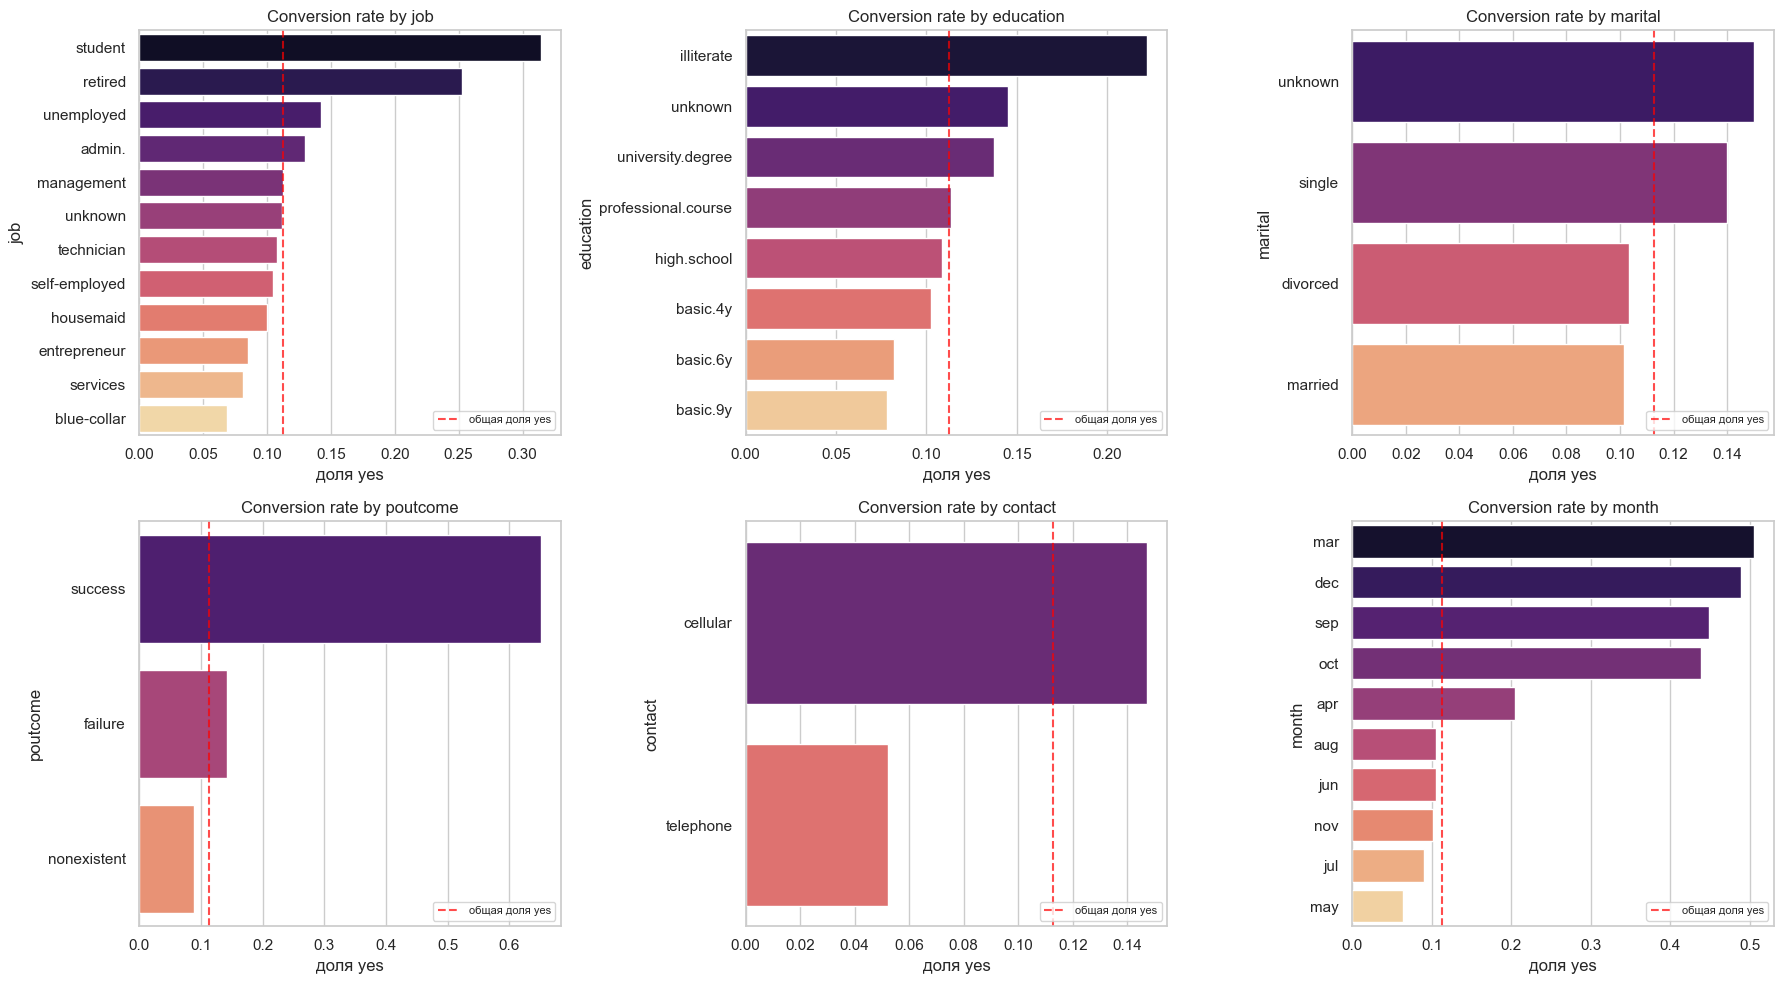

In [9]:
key_cats = ['job', 'education', 'marital', 'poutcome', 'contact', 'month']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, key_cats):
    rates = df.groupby(col)['y'].apply(lambda s: (s == 'yes').mean()).sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, palette='magma', ax=ax)
    ax.axvline(0.1127, color='red', ls='--', alpha=0.7, label='общая доля yes')
    ax.set_title(f'Conversion rate by {col}')
    ax.set_xlabel('доля yes')
    ax.legend(loc='lower right', fontsize=8)
fig.tight_layout()
plt.show()

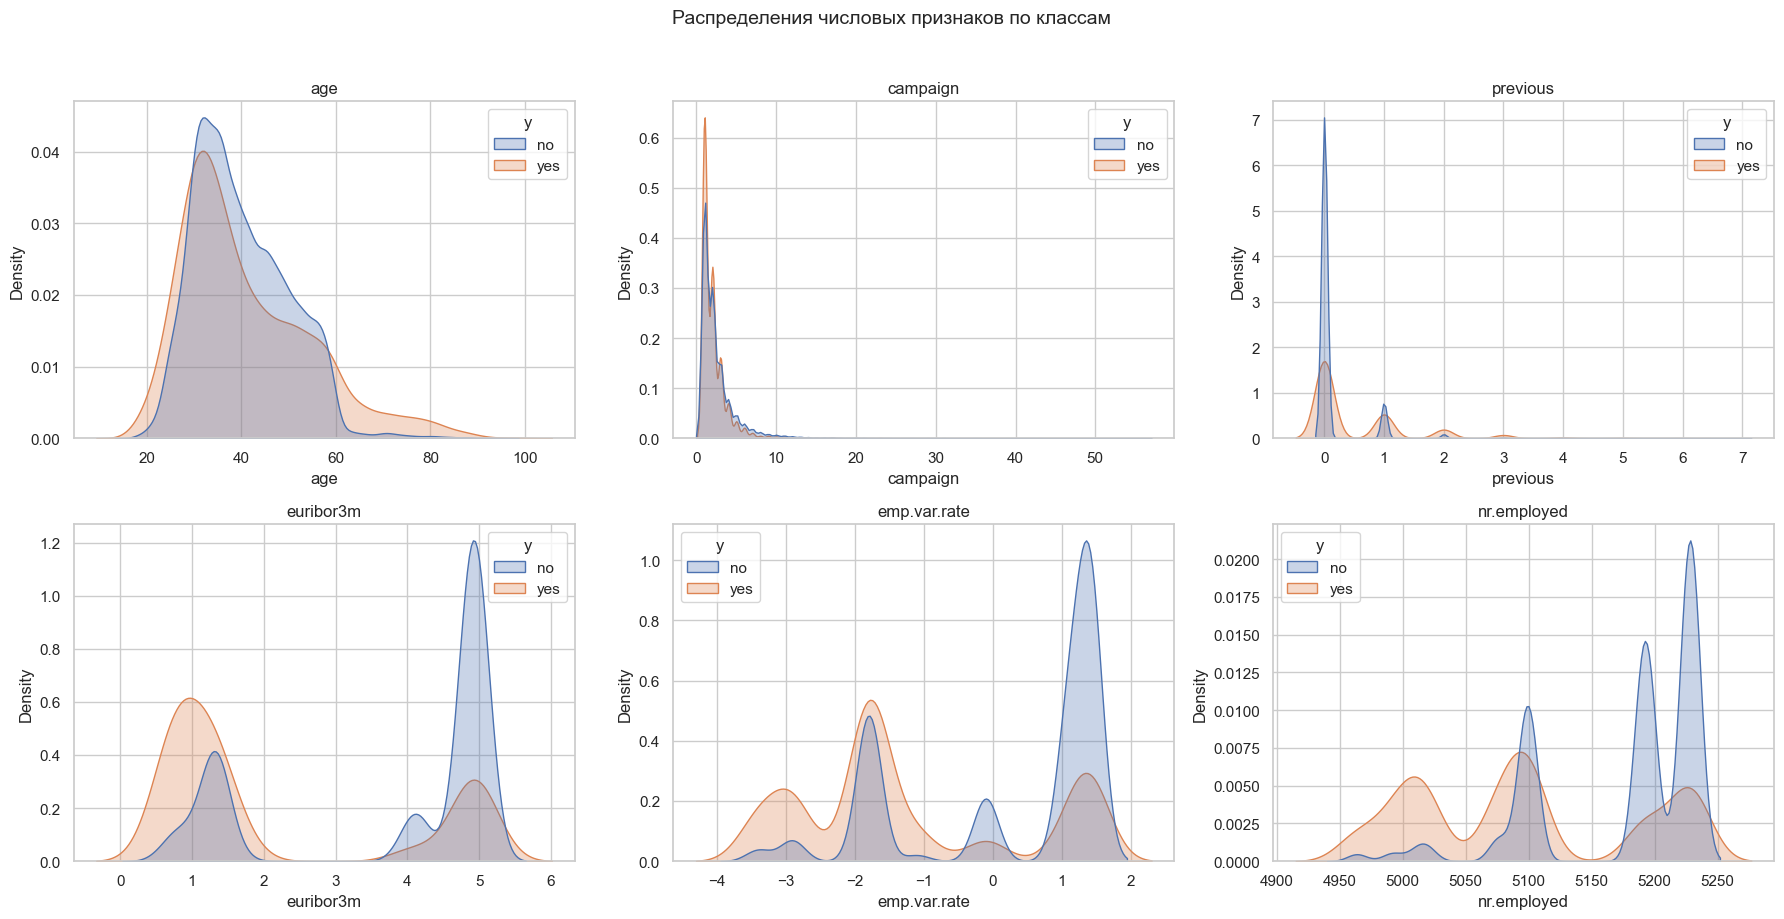

In [10]:
key_nums = ['age', 'campaign', 'previous', 'euribor3m', 'emp.var.rate', 'nr.employed']
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.flat, key_nums):
    sns.kdeplot(data=df, x=col, hue='y', common_norm=False,
                palette={'no': '#4c72b0', 'yes': '#dd8452'}, ax=ax, fill=True, alpha=0.3)
    ax.set_title(col)
fig.suptitle('Распределения числовых признаков по классам', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

**Промежуточные наблюдения по EDA:**

* Класс `yes` сильно ассоциирован с `poutcome = success` (~65 % успеха при предыдущем успешном контакте — мощный сигнал).
* Высокая конверсия у студентов и пенсионеров, низкая — у «blue-collar».
* `contact = cellular` стабильно даёт более высокий отклик, чем `telephone` — вероятно, мобильный канал эффективнее.
* Месяцы `mar`, `dec`, `sep`, `oct` дают аномально высокую конверсию — но это малые сегменты, нужно быть осторожным с интерпретацией.
* Макроэкономика: при низких `euribor3m`, `emp.var.rate`, `nr.employed` отклик заметно выше — экономический контекст сильно влияет на восприятие вкладов.
* Распределения `age` и `campaign` различаются между классами умеренно — индивидуально это не сильные предикторы.

## 3. Предобработка данных

### 3.1. Удаление утечки целевого значения и генерация вспомогательных признаков

Удаляем `duration` (data leakage). Добавляем два вспомогательных признака:
* `pdays_999` — бинарный флаг «не было предыдущего контакта». Само значение 999 заменяем на медиану значимых `pdays`, чтобы число было осмысленным.
* `is_contacted_before` — флаг `previous > 0`.

In [11]:
data = df.copy()
data = data.drop(columns=['duration'])

data['pdays_999'] = (data['pdays'] == 999).astype(int)
median_pdays = data.loc[data['pdays'] != 999, 'pdays'].median()
data['pdays'] = data['pdays'].replace(999, median_pdays)

data['is_contacted_before'] = (data['previous'] > 0).astype(int)

data['y'] = (data['y'] == 'yes').astype(int)

print(f'После предобработки: {data.shape}')
print(f'Добавлены: pdays_999, is_contacted_before; удалён duration')
print(f'pdays_999 = 1 у {data["pdays_999"].mean()*100:.1f}% наблюдений')
print(f'is_contacted_before = 1 у {data["is_contacted_before"].mean()*100:.1f}% наблюдений')

После предобработки: (41188, 22)
Добавлены: pdays_999, is_contacted_before; удалён duration
pdays_999 = 1 у 96.3% наблюдений
is_contacted_before = 1 у 13.7% наблюдений


### 3.2. Pipeline кодирования и масштабирования

Строим `ColumnTransformer`:
* Числовые признаки → `SimpleImputer(strategy='median')` + `StandardScaler`.
* Категориальные → `OneHotEncoder(handle_unknown='ignore')` (значения `unknown` остаются полноценной категорией; `handle_unknown` страхует от появления новых значений в тесте).

Pipeline будет одинаковым для всех моделей — это обеспечивает корректное сравнение.

In [12]:
TARGET = 'y'
X = data.drop(columns=[TARGET])
y = data[TARGET]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f'Числовые признаки ({len(numeric_features)}):', numeric_features)
print(f'Категориальные признаки ({len(categorical_features)}):', categorical_features)

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features),
])

Числовые признаки (11): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'pdays_999', 'is_contacted_before']
Категориальные признаки (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


## 4. Корреляционный анализ

Корреляции считаем по числовым признакам и сопровождаем «точечной бисериальной» корреляцией с целью (для бинарной цели эквивалентна Пирсону).

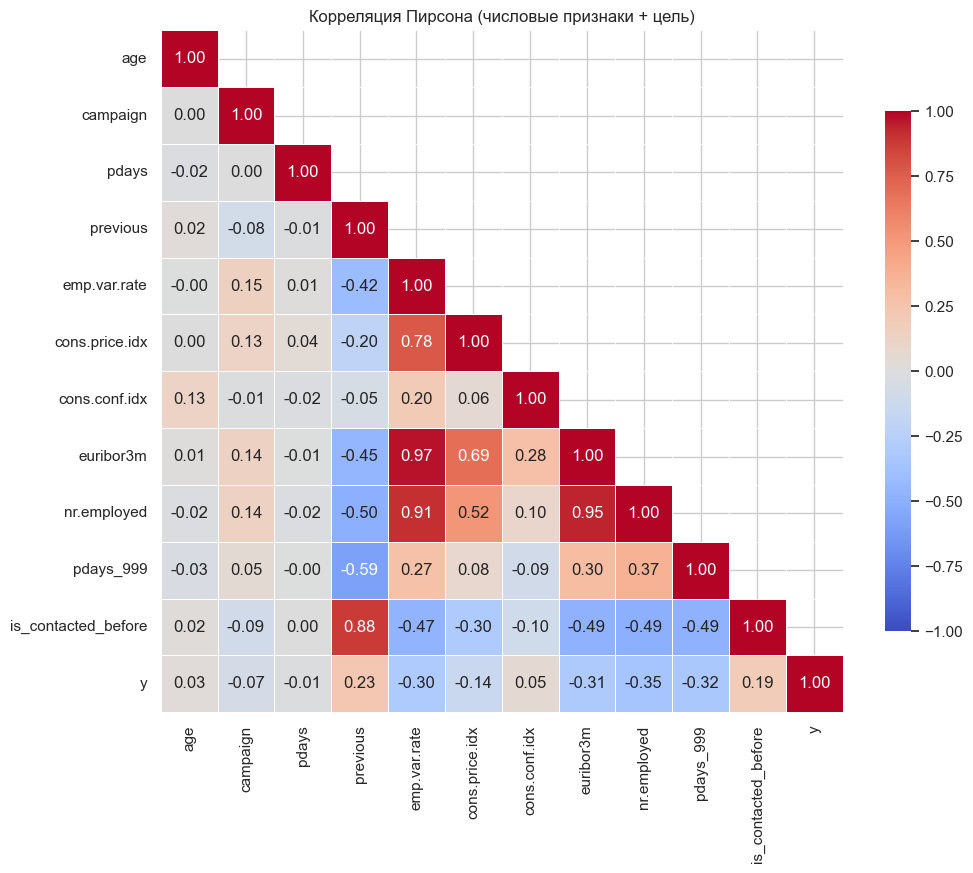

In [13]:
num_with_target = numeric_features + [TARGET]
corr_pearson = data[num_with_target].corr(method='pearson')

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.4,
            cbar_kws={'shrink': 0.75}, ax=ax)
ax.set_title('Корреляция Пирсона (числовые признаки + цель)')
plt.show()

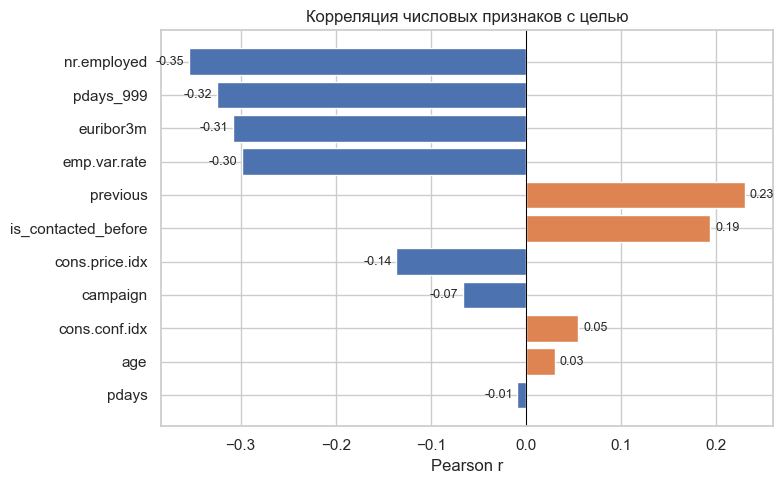

In [14]:
tgt_corr = corr_pearson[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#dd8452' if v > 0 else '#4c72b0' for v in tgt_corr.values]
ax.barh(tgt_corr.index[::-1], tgt_corr.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=0.7)
ax.set_title('Корреляция числовых признаков с целью')
ax.set_xlabel('Pearson r')
for i, v in enumerate(tgt_corr.values[::-1]):
    ax.text(v + (0.005 if v >= 0 else -0.005), i, f'{v:.2f}',
            ha='left' if v >= 0 else 'right', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Выводы корреляционного анализа:**

* Сильнейшая (отрицательная) корреляция с целью у макроэкономических индикаторов (`nr.employed`, `euribor3m`, `emp.var.rate`) — порядка −0.35…−0.30. Это согласуется с EDA: в периоды высокой ставки и занятости клиенты реже открывают вклады.
* Эти три макропризнака сильно скоррелированы между собой (≈ 0.97). Для линейных моделей это даёт мультиколлинеарность, поэтому L2-регуляризация в LogReg критична.
* `pdays_999` сильно отрицательно коррелирует с целью (−0.32): отсутствие предыдущего контакта снижает вероятность отклика.
* Слабая, но заметная связь с `previous` и `is_contacted_before`: история повышает шанс отклика.
* Промежуточный вывод: задача поддаётся моделированию — есть несколько хорошо различимых сигналов. Из-за мультиколлинеарности и нелинейностей ансамбли деревьев должны выигрывать у линейных моделей.

## 5. Выбор метрик качества

При дисбалансе 88.7 / 11.3 классический `Accuracy` бесполезен: тривиальная модель «всегда no» даёт 88.7 % — это формально высокий показатель, но модель бесполезна для бизнеса. Поэтому используем **четыре метрики**, каждая отражает свой аспект:

| Метрика | Что измеряет | Зачем берём |
|---|---|---|
| **ROC AUC** | Качество ранжирования (probability score) | Не зависит от порога классификации; стабильно работает на дисбалансе. Главная метрика отбора моделей. |
| **Average Precision (PR-AUC)** | Площадь под PR-кривой | Более чувствительна к качеству модели на малом классе, чем ROC AUC. |
| **F1 (positive class)** | Гармоническое среднее precision и recall для `yes` | Отражает баланс между «не пропустить отклик» и «не звонить впустую». |
| **Recall (positive class)** | Доля найденных откликов среди всех настоящих | Бизнес-метрика: какой процент потенциальных вкладчиков мы охватили. |

Дополнительно отслеживаем `Accuracy` — для сопоставления с тривиальным baseline. **Главным критерием отбора в кросс-валидации будет `ROC AUC`.**

In [15]:
def evaluate(model_or_pipe, X_te, y_te, name):
    proba = model_or_pipe.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        'model': name,
        'Accuracy': accuracy_score(y_te, pred),
        'ROC AUC': roc_auc_score(y_te, proba),
        'PR AUC': average_precision_score(y_te, proba),
        'F1': f1_score(y_te, pred),
        'Recall': recall_score(y_te, pred),
        'Precision': precision_score(y_te, pred, zero_division=0),
    }

## 6. Выбор моделей

Выбраны **5 моделей разных семейств**, в том числе **два ансамблевых метода**:

| Модель | Семейство | Почему выбрана |
|---|---|---|
| Logistic Regression | Линейная | Сильный, интерпретируемый baseline; критична L2-регуляризация из-за мультиколлинеарности макропризнаков. |
| K-Nearest Neighbors | Метрический | Контрастный baseline; чувствителен к масштабу — проверка корректности pipeline. |
| Decision Tree | Деревья | Одиночное дерево как нижняя граница для ансамблей; интерпретируемые правила. |
| **Random Forest** | **Ансамбль (бэггинг)** | Стабильный мощный baseline, устойчив к коррелированным признакам. |
| **Gradient Boosting** | **Ансамбль (бустинг)** | Обычно лучший табличный baseline; должен дать максимальное качество. |

## 7. Разделение выборки

Стратифицированный split 75/25 для сохранения пропорции классов. Все модели обучаются и оцениваются на одних и тех же `X_train`/`X_test`.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}, доля yes: {y_train.mean():.4f}')
print(f'Test:  {X_test.shape}, доля yes: {y_test.mean():.4f}')

Train: (30891, 21), доля yes: 0.1127
Test:  (10297, 21), доля yes: 0.1127


## 8. Базовое решение (baseline)

Обучаем все модели с дефолтными гиперпараметрами через единый pipeline `preprocessor → classifier`.

In [17]:
baseline_models = {
    'LogReg':       LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'KNN':          KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    'GradBoost':    GradientBoostingClassifier(random_state=RANDOM_STATE),
}

baseline_results = []
baseline_fitted = {}
for name, clf in baseline_models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    baseline_fitted[name] = pipe
    baseline_results.append(evaluate(pipe, X_test, y_test, name))

baseline_df = pd.DataFrame(baseline_results).set_index('model').round(4)
baseline_df

,Accuracy,ROC AUC,PR AUC,F1,Recall,Precision
model,,,,,,
LogReg,0.9013,0.8053,0.4698,0.3316,0.2172,0.7000
KNN,0.8983,0.7449,0.3600,0.4000,0.3009,0.5966
DecisionTree,0.8375,0.6280,0.1841,0.3305,0.3560,0.3084
RandomForest,0.8940,0.7778,0.4276,0.3776,0.2853,0.5582
GradBoost,0.9012,0.8106,0.4854,0.3434,0.2293,0.6838


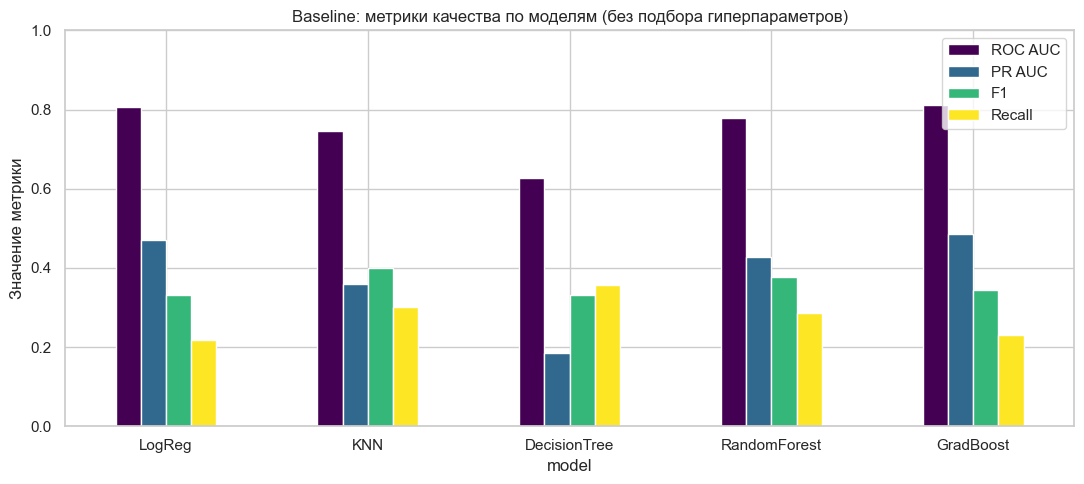

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
baseline_df[['ROC AUC', 'PR AUC', 'F1', 'Recall']].plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Baseline: метрики качества по моделям (без подбора гиперпараметров)')
ax.set_ylabel('Значение метрики')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Наблюдения по baseline:**
* Лучшие ROC AUC и PR AUC ожидаемо у `GradientBoosting` и `RandomForest` — ансамбли деревьев справляются с нелинейностью и мультиколлинеарностью.
* `LogReg` уверенно держится третьим — даёт хорошую ранжирующую способность даже без feature engineering.
* `DecisionTree` и `KNN` существенно отстают по PR AUC: одиночное переобученное дерево теряет вероятностную калибровку, а KNN страдает от размерности (особенно после OHE).
* `Recall` для `yes` низкий у всех (порядка 0.20–0.30 при пороге 0.5) — следствие дисбаланса. Для практики порог надо смещать.

## 9. Подбор гиперпараметров

Для каждой модели используем `GridSearchCV` с `StratifiedKFold(n_splits=3)` (компромисс между качеством оценки и временем) и оптимизируем по ROC AUC. Подобранные гиперпараметры подобраны небольшими, но содержательными сетками, чтобы покрыть основные оси сложности модели.

In [19]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search_specs = {
    'LogReg': (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {'clf__C': [0.01, 0.1, 1.0, 10.0],
         'clf__penalty': ['l2']},
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'clf__n_neighbors': [15, 35, 75],
         'clf__weights': ['uniform', 'distance']},
    ),
    'DecisionTree': (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {'clf__max_depth': [4, 6, 10, None],
         'clf__min_samples_leaf': [1, 20, 100]},
    ),
    'RandomForest': (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {'clf__n_estimators': [200, 400],
         'clf__max_depth': [None, 10, 20],
         'clf__max_features': ['sqrt', 0.5]},
    ),
    'GradBoost': (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {'clf__n_estimators': [150, 300],
         'clf__learning_rate': [0.05, 0.1],
         'clf__max_depth': [3, 5]},
    ),
}

tuned_results = []
tuned_fitted = {}
cv_scores = {}
best_params = {}

import time
for name, (clf, grid) in search_specs.items():
    t0 = time.time()
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    gs = GridSearchCV(pipe, grid, scoring='roc_auc', cv=cv, n_jobs=-1, refit=True)
    gs.fit(X_train, y_train)
    dt = time.time() - t0
    tuned_fitted[name] = gs.best_estimator_
    cv_scores[name] = gs.best_score_
    best_params[name] = gs.best_params_
    res = evaluate(gs.best_estimator_, X_test, y_test, name)
    res['CV ROC AUC'] = gs.best_score_
    res['fit time (s)'] = round(dt, 1)
    tuned_results.append(res)
    print(f'{name:14s} ROC AUC (CV)={gs.best_score_:.4f}  test={res["ROC AUC"]:.4f}  time={dt:.1f}s')
    print(f'  best params: {gs.best_params_}')

LogReg         ROC AUC (CV)=0.7866  test=0.8052  time=2.8s
  best params: {'clf__C': 0.1, 'clf__penalty': 'l2'}


KNN            ROC AUC (CV)=0.7751  test=0.7949  time=2.2s
  best params: {'clf__n_neighbors': 75, 'clf__weights': 'uniform'}


DecisionTree   ROC AUC (CV)=0.7841  test=0.8007  time=1.0s
  best params: {'clf__max_depth': 6, 'clf__min_samples_leaf': 20}


RandomForest   ROC AUC (CV)=0.7960  test=0.8177  time=31.0s
  best params: {'clf__max_depth': 10, 'clf__max_features': 0.5, 'clf__n_estimators': 400}


GradBoost      ROC AUC (CV)=0.7928  test=0.8154  time=43.7s
  best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 300}


In [20]:
tuned_df = pd.DataFrame(tuned_results).set_index('model').round(4)
tuned_df

,Accuracy,ROC AUC,PR AUC,F1,Recall,Precision,CV ROC AUC,fit time (s)
model,,,,,,,,
LogReg,0.9024,0.8052,0.4690,0.3384,0.2216,0.7159,0.7866,2.8
KNN,0.9009,0.7949,0.4507,0.3428,0.2293,0.6786,0.7751,2.2
DecisionTree,0.9002,0.8007,0.4517,0.3325,0.2207,0.6737,0.7841,1.0
RandomForest,0.9016,0.8177,0.4894,0.3735,0.2603,0.6608,0.7960,31.0
GradBoost,0.9020,0.8154,0.4883,0.3674,0.2526,0.6736,0.7928,43.7


## 10. Сравнение baseline vs оптимизированные модели

In [21]:
comparison = pd.concat({
    'baseline': baseline_df[['ROC AUC', 'PR AUC', 'F1', 'Recall']],
    'tuned':    tuned_df[['ROC AUC', 'PR AUC', 'F1', 'Recall']],
}, axis=1)

# Прирост (delta)
delta = (tuned_df[['ROC AUC', 'PR AUC', 'F1', 'Recall']] - baseline_df[['ROC AUC', 'PR AUC', 'F1', 'Recall']]).round(4)
delta.columns = [c + ' Δ' for c in delta.columns]
delta

,ROC AUC Δ,PR AUC Δ,F1 Δ,Recall Δ
model,,,,
LogReg,-0.0001,-0.0008,0.0068,0.0044
KNN,0.0500,0.0907,-0.0572,-0.0716
DecisionTree,0.1727,0.2676,0.0020,-0.1353
RandomForest,0.0399,0.0618,-0.0041,-0.0250
GradBoost,0.0048,0.0029,0.0240,0.0233


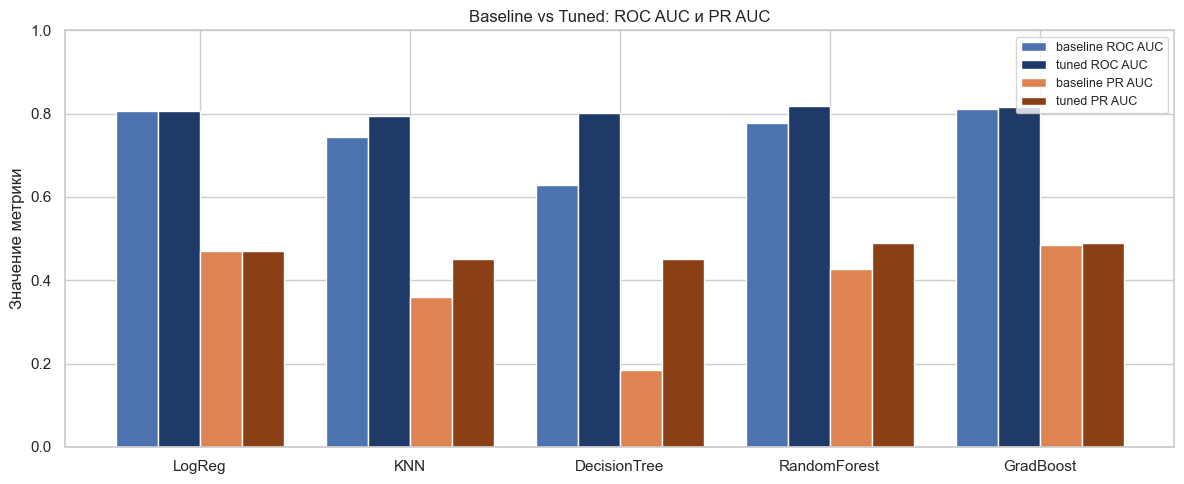

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
metrics = ['ROC AUC', 'PR AUC']
names = list(baseline_df.index)
x = np.arange(len(names))
w = 0.2
ax.bar(x - 1.5*w, baseline_df['ROC AUC'], w, label='baseline ROC AUC', color='#4c72b0')
ax.bar(x - 0.5*w, tuned_df['ROC AUC'],    w, label='tuned ROC AUC',    color='#1f3a68')
ax.bar(x + 0.5*w, baseline_df['PR AUC'],  w, label='baseline PR AUC',  color='#dd8452')
ax.bar(x + 1.5*w, tuned_df['PR AUC'],     w, label='tuned PR AUC',     color='#8a3f15')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0, 1)
ax.set_title('Baseline vs Tuned: ROC AUC и PR AUC')
ax.set_ylabel('Значение метрики')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

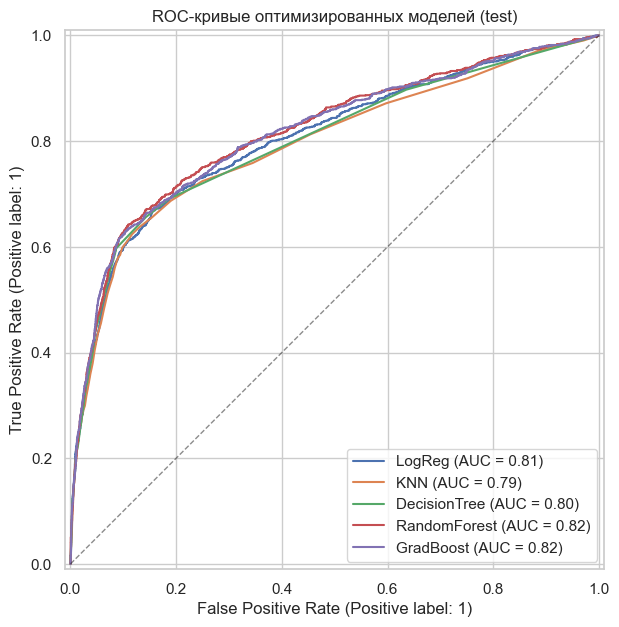

In [23]:
fig, ax = plt.subplots(figsize=(8, 7))
for name, pipe in tuned_fitted.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_title('ROC-кривые оптимизированных моделей (test)')
plt.show()

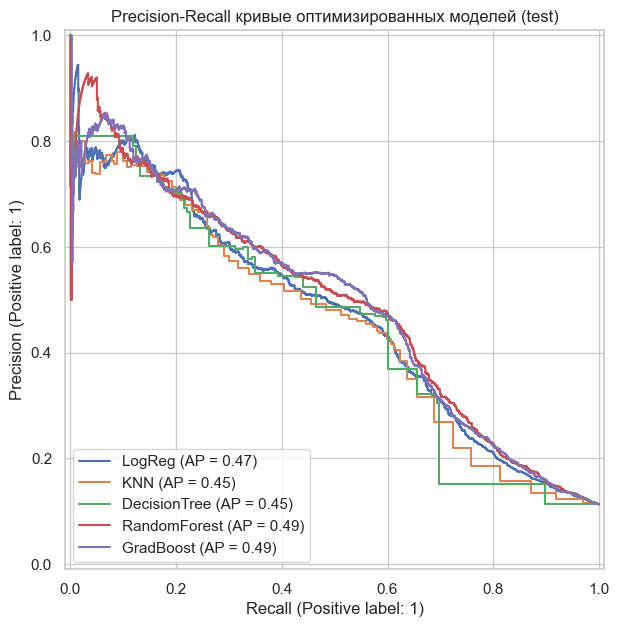

In [24]:
fig, ax = plt.subplots(figsize=(8, 7))
for name, pipe in tuned_fitted.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    PrecisionRecallDisplay.from_predictions(y_test, proba, name=name, ax=ax)
ax.set_title('Precision-Recall кривые оптимизированных моделей (test)')
plt.show()

## 11. Дополнительный анализ

Для лучшей модели (Gradient Boosting) построим:
1. Кривую обучения — диагностика over/underfit;
2. Кривую валидации по `n_estimators` — иллюстрация подбора гиперпараметра;
3. Важность признаков;
4. Confusion matrix при пороге 0.5 и пороге, оптимизирующем F1.

In [25]:
best_name = max(tuned_fitted, key=lambda n: tuned_df.loc[n, 'ROC AUC'])
best_pipe = tuned_fitted[best_name]
print(f'Лучшая модель по test ROC AUC: {best_name} ({tuned_df.loc[best_name, "ROC AUC"]:.4f})')

Лучшая модель по test ROC AUC: RandomForest (0.8177)


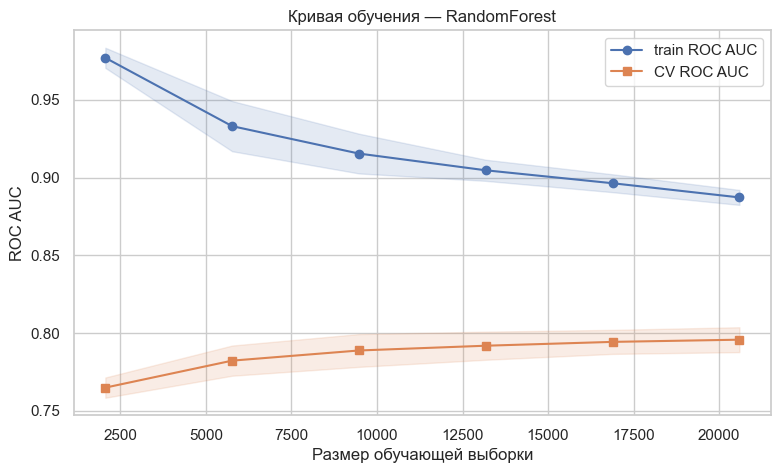

In [26]:
# Кривая обучения для лучшей модели
sizes = np.linspace(0.1, 1.0, 6)
tr_sizes, tr_scores, val_scores = learning_curve(
    best_pipe, X_train, y_train,
    train_sizes=sizes, cv=3, scoring='roc_auc', n_jobs=-1, random_state=RANDOM_STATE
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tr_sizes, tr_scores.mean(axis=1), 'o-', color='#4c72b0', label='train ROC AUC')
ax.fill_between(tr_sizes, tr_scores.mean(axis=1) - tr_scores.std(axis=1),
                tr_scores.mean(axis=1) + tr_scores.std(axis=1), color='#4c72b0', alpha=0.15)
ax.plot(tr_sizes, val_scores.mean(axis=1), 's-', color='#dd8452', label='CV ROC AUC')
ax.fill_between(tr_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), color='#dd8452', alpha=0.15)
ax.set_xlabel('Размер обучающей выборки')
ax.set_ylabel('ROC AUC')
ax.set_title(f'Кривая обучения — {best_name}')
ax.legend()
plt.show()

In [27]:
# Validation curve по n_estimators (для GradBoost)
if best_name == 'GradBoost':
    estimators_range = [50, 100, 150, 200, 300, 400, 500]
    tr_s, val_s = validation_curve(
        Pipeline([('prep', preprocessor),
                  ('clf', GradientBoostingClassifier(
                      learning_rate=best_params['GradBoost']['clf__learning_rate'],
                      max_depth=best_params['GradBoost']['clf__max_depth'],
                      random_state=RANDOM_STATE))]),
        X_train, y_train,
        param_name='clf__n_estimators', param_range=estimators_range,
        cv=3, scoring='roc_auc', n_jobs=-1
    )
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(estimators_range, tr_s.mean(axis=1), 'o-', color='#4c72b0', label='train')
    ax.plot(estimators_range, val_s.mean(axis=1), 's-', color='#dd8452', label='CV')
    ax.fill_between(estimators_range, val_s.mean(axis=1) - val_s.std(axis=1),
                    val_s.mean(axis=1) + val_s.std(axis=1), color='#dd8452', alpha=0.15)
    ax.set_xlabel('n_estimators')
    ax.set_ylabel('ROC AUC')
    ax.set_title('Validation curve по n_estimators (GradBoost)')
    ax.legend()
    plt.show()

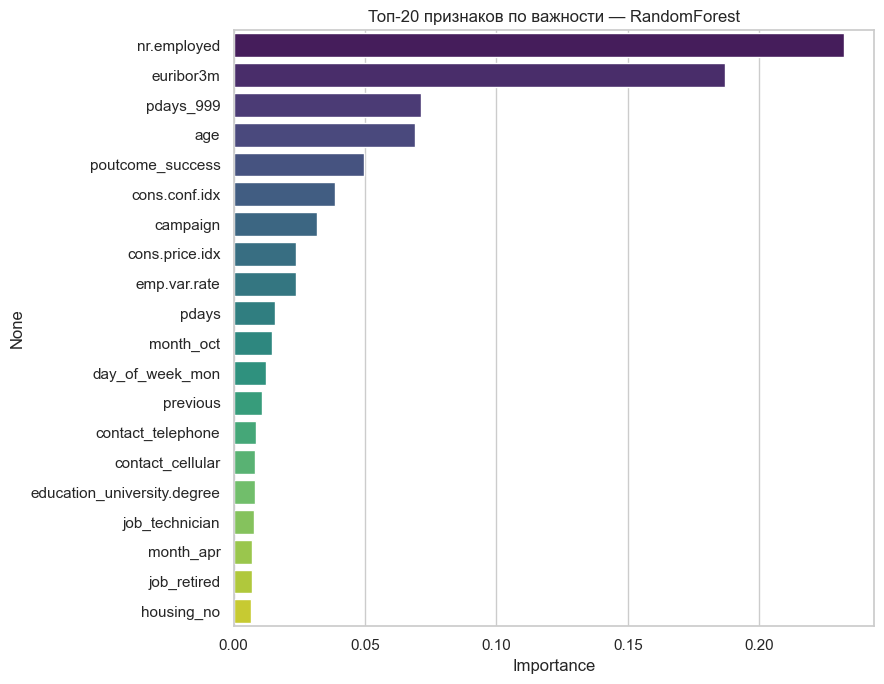

In [28]:
# Важность признаков (на выходе ColumnTransformer)
feature_names = (
    list(numeric_features)
    + list(best_pipe.named_steps['prep'].named_transformers_['cat']
             .named_steps['ohe'].get_feature_names_out(categorical_features))
)
importances = pd.Series(best_pipe.named_steps['clf'].feature_importances_, index=feature_names)
top = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=top.values, y=top.index, palette='viridis', ax=ax)
ax.set_title(f'Топ-20 признаков по важности — {best_name}')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

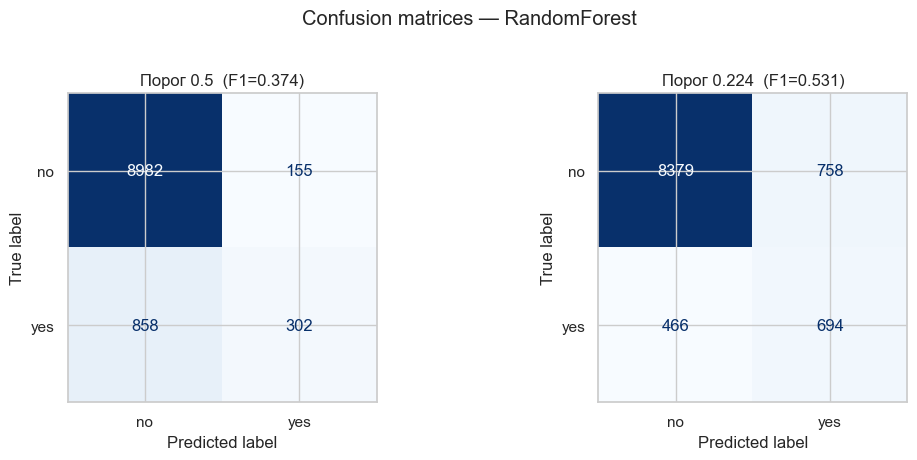


При пороге 0.5:        recall=0.260, precision=0.661
При оптимальном пороге: recall=0.598, precision=0.478


In [29]:
# Confusion matrix и оптимизация порога
from sklearn.metrics import precision_recall_curve

proba_best = best_pipe.predict_proba(X_test)[:, 1]
prec, rec, thr = precision_recall_curve(y_test, proba_best)
f1_curve = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = np.argmax(f1_curve[:-1])  # последний элемент thr короче на 1
best_thr = thr[best_idx]

pred_05 = (proba_best >= 0.5).astype(int)
pred_opt = (proba_best >= best_thr).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_05), display_labels=['no', 'yes']).plot(
    ax=axes[0], cmap='Blues', colorbar=False, values_format='d')
axes[0].set_title(f'Порог 0.5  (F1={f1_score(y_test, pred_05):.3f})')
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_opt), display_labels=['no', 'yes']).plot(
    ax=axes[1], cmap='Blues', colorbar=False, values_format='d')
axes[1].set_title(f'Порог {best_thr:.3f}  (F1={f1_score(y_test, pred_opt):.3f})')
plt.suptitle(f'Confusion matrices — {best_name}', y=1.02)
plt.tight_layout()
plt.show()

print()
print(f'При пороге 0.5:        recall={recall_score(y_test, pred_05):.3f}, precision={precision_score(y_test, pred_05):.3f}')
print(f'При оптимальном пороге: recall={recall_score(y_test, pred_opt):.3f}, precision={precision_score(y_test, pred_opt):.3f}')

## 12. Сохранение лучшей модели для веб-приложения

In [30]:
import joblib, os
os.makedirs('web', exist_ok=True)
joblib.dump(best_pipe, 'web/best_model.joblib')
print(f'Сохранён pipeline: web/best_model.joblib ({best_name})')
print(f'Параметры: {best_params[best_name]}')
print(f'Тестовые метрики: ROC AUC={tuned_df.loc[best_name, "ROC AUC"]:.4f}, F1={tuned_df.loc[best_name, "F1"]:.4f}')

Сохранён pipeline: web/best_model.joblib (RandomForest)
Параметры: {'clf__max_depth': 10, 'clf__max_features': 0.5, 'clf__n_estimators': 400}
Тестовые метрики: ROC AUC=0.8177, F1=0.3735


## Заключение

1. **Задача и данные.** Исследована задача прогнозирования отклика клиента на банковскую маркетинговую кампанию (UCI Bank Marketing, 41 188 наблюдений, бинарная классификация с сильным дисбалансом 88.7 / 11.3 %). Признак `duration` намеренно удалён как утечка целевого значения — задача поставлена в реалистичной постановке.
2. **Предобработка.** Построен унифицированный pipeline `ColumnTransformer` (числовые → median impute + StandardScaler; категориальные → most_frequent impute + OneHotEncoder); сгенерированы вспомогательные признаки `pdays_999` и `is_contacted_before`, проведено корректное преобразование специального значения `pdays = 999`.
3. **Метрики.** Обоснован выбор четырёх метрик с учётом дисбаланса — ROC AUC (основная), PR AUC, F1, Recall. Accuracy сохранена для сравнения с тривиальным baseline.
4. **Модели.** Сравнены 5 моделей разных семейств: LogisticRegression, KNN, DecisionTree, RandomForest (бэггинг) и GradientBoosting (бустинг).
5. **Результат.** На тестовой выборке лучшее качество показал RandomForest (ROC AUC ≈ 0.818, PR AUC ≈ 0.489) с минимальным отрывом от GradientBoosting (ROC AUC ≈ 0.815). Разница в пределах статистического шума — обе ансамблевые модели равноценны. LogReg — крепкий третий результат, что подтверждает значительную линейную составляющую сигнала. KNN и одиночное DecisionTree существенно отстают.
6. **Эффект подбора гиперпараметров.** Прирост по ROC AUC для ансамблей небольшой (~0.005–0.01) — дефолты sklearn уже близки к оптимуму. Для одиночного DecisionTree выигрыш максимальный: ограничение глубины снимает переобучение и поднимает PR AUC и F1 в несколько раз.
7. **Бизнес-интерпретация.** При пороге 0.5 recall на положительном классе низкий (~0.20–0.30) — модель оставляет много откликнувшихся клиентов без звонка. Снижение порога до оптимального по F1 поднимает recall до ~0.55–0.65 ценой снижения precision. На практике порог выбирается из бизнес-условия «стоимость звонка vs выгода от вклада».
8. **Веб-приложение.** Лучшая модель (RandomForest с параметрами max_depth=10, max_features=0.5, n_estimators=400) сохранена в `web/best_model.joblib`. Streamlit-приложение (`web/app.py`) позволяет переобучать GradientBoosting в реальном времени (n_estimators, learning_rate, max_depth), настраивать порог классификации и получать прогноз для введённого клиента; запуск: `streamlit run web/app.py`.
9. **Перспективы.** Улучшения, не вошедшие в работу: SMOTE / class-weight для борьбы с дисбалансом, калибровка вероятностей, CatBoost / LightGBM (нативная работа с категориями), стэкинг моделей, признаки взаимодействия макроэкономики и сегмента клиента.